## Deep Reinforcement Learning on Grid World Assignment

### Instructions :

1. Initialisez le Grid World avec une largeur, une hauteur et des positions bloquées données.
    - Créez une grille bidimensionnelle représentant le monde avec la largeur et la hauteur spécifiées.
    - Marquez toutes les positions bloquées sur la grille.
    - Spécifiez une position de départ et une position d'arrivée sur la grille.
    - Lancez une simulation avec un agent aléatoire.

2. Créez un Replay Buffer (mémoire tampon de rejouement).
    - Implémentez une classe Replay Buffer capable de stocker et d'échantillonner des expériences pour entraîner l'agent DQN.
    - Chaque expérience doit contenir l'état courant, l'action effectuée, la récompense reçue, l'état suivant et un indicateur (done) signalant si l'épisode est terminé.

3. Créez un réseau de neurones convolutif pour l'apprentissage d'un agent DQN.
    - Définissez un CNN avec Pytorch contenant 3 couches de convolution et 2 couches linéaires.

4. Implémentez un agent DQN pour naviguer dans le Grid World.
    - Implémentez une classe d'agent DQN qui utilise un réseau de neurones pour approximer les Q-valeurs pour chaque paire état-action.
    - Utilisez une politique epsilon-greedy pour sélectionner les actions pendant l'entraînement.
    - Utilisez le replay buffer pour échantillonner des expériences et entraîner l'agent DQN à mettre à jour ses Q-valeurs.
    - Entraînez l'agent à atteindre la position d'arrivée depuis la position de départ tout en évitant les positions bloquées.

5. Expérimentation
    - Entraînez l'agent DQN à naviguer de la position de départ à la position d'arrivée tout en évitant les positions bloquées.
    - Expérimentez avec différentes valeurs d'hyperparamètres, comme le taux d'apprentissage, le facteur d'actualisation, la taille du batch, la récompense, et observez leurs effets sur l'apprentissage de l'agent DQN.
    - Analysez la performance de l'agent en mesurant le nombre d'étapes nécessaires pour atteindre l'objectif à chaque épisode.

6. Simulation
    - Visualisez le chemin de l'agent de la position de départ à la position d'arrivée.
    - Simulez l'agent avec la politique sauvegardée à un épisode spécifique.

7. (Optionnel)
    - Proposez une configuration difficile et observez la performance de l'agent DQN.

8. Questions :
    - Expliquez le rôle du réseau de neurones et la motivation de son utilisation.
    - Expliquez le rôle de la mémoire de rejouement et du minibatch.
    - Expliquez le choix des différents composants de la mémoire de rejouement et leur importance dans l'apprentissage.
    - Expliquez la relation entre la fonction de perte du DQN et la fonction de mise à jour des Q-valeurs dans le Q-Learning.


INTRO : A faire
à améliorer : Erreur dans get_state() 

## Pourquoi le DQN ?

Avant d’introduire le Deep Q-Network (DQN), il est nécessaire de comprendre pourquoi il a été développé. En apprentissage par renforcement, l’objectif est d’estimer une fonction de valeur d’action notée $Q(s,a)$, qui mesure la qualité d’une action $a$ dans un état $s$.

Une première approche consiste à utiliser une Q-table, où chaque paire état-action possède une valeur stockée explicitement. Cette méthode devient rapidement impraticable lorsque l’espace d’état est grand, car elle nécessite de stocker $|S| \times |A|$ valeurs. De plus, l’apprentissage est lent, car il faut explorer un grand nombre de fois les états, et il n’y a aucune généralisation : chaque état est traité indépendamment. Enfin, pour des états continus, il faut discrétiser, ce qui introduit des erreurs et reste difficile à calibrer.

Pour pallier ces limites, on peut utiliser une approximation linéaire de la fonction $Q$, définie par $Q_w(s,a) = \sum_i w_i f_i(s,a)$, où $f_i(s,a)$ sont des caractéristiques et $w_i$ des poids appris. Cette approche réduit la mémoire et permet une certaine généralisation. Toutefois, elle dépend fortement du choix des caractéristiques, souvent difficile à concevoir, et reste limitée car elle ne peut modéliser que des relations linéaires.

La solution consiste alors à utiliser une approximation non linéaire, typiquement via un réseau de neurones. Celui-ci permet d’approximer directement la fonction $Q(s,a)$ en apprenant automatiquement des représentations pertinentes à partir des données. Il est capable de capturer des relations complexes et de généraliser à des états jamais vus.

Le DQN repose précisément sur cette idée : remplacer la Q-table ou les modèles linéaires par un réseau de neurones afin de traiter efficacement des espaces d’état de grande dimension.
On va maintenant appliquer cette méthode dans l'exemple de GridWorld : 

### GridWorld Environment

In [29]:
from collections import deque

On définit premièrement l’environnement GridWorld, pour entraîner notre agent par DQN ; l’ensemble simule une grille dans laquelle un agent (le joueur) doit se déplacer pour atteindre un objectif.
L’agent interagit avec cet environnement en choisissant des actions (haut, bas, gauche, droite), ce qui modifie sa position dans la grille.
À chaque déplacement, il reçoit une récompense qui guide son apprentissage et lui permet d’évaluer la qualité de ses actions.
L’objectif est alors d’apprendre une stratégie optimale permettant d’atteindre la cible le plus efficacement possible.

Remarque : La fonction de récompense a été modifiée pour renforcer le signal d’apprentissage (récompense plus élevée pour l’objectif et pénalité plus forte par étape). Avoir des rewards optimisé améliore la vitesse de convergence. à verif

In [30]:
import random
import numpy as np
class GridWorld:
    def __init__(self, width, height, blocked_positions=None):

        self.width = width
        self.height = height
        self.player_position = (0, 0)
        self.goal_position = (width - 1, height - 1)
        self.blocked_positions = blocked_positions if blocked_positions else []
        self.observation_space = (2, self.height, self.width)
        self.action_space = 4
        self.actions = ["up", "down", "left", "right",]

    def make_action(self, action:int):
        self.move_player(self.actions[action])

    def move_player(self, direction):
        x, y = self.player_position
        if direction == "up":
            y = max(0, y - 1)
        elif direction == "down":
            y = min(self.height - 1, y + 1)
        elif direction == "left":
            x = max(0, x - 1)
        elif direction == "right":
            x = min(self.width - 1, x + 1)
        
        # Check if the new position is blocked
        if (x, y) not in self.blocked_positions:
            self.player_position = (x, y)
        return self.player_position == self.goal_position

    def print_grid(self):
        for y in range(self.height):
            row = ""
            for x in range(self.width):
                if (x, y) == self.player_position:
                    row += "P"
                elif (x, y) == self.goal_position:
                    row += "G"
                elif (x, y) in self.blocked_positions:
                    row += "B"
                else:
                    row += "."
            print(row)
            
    def is_game_over(self):
        return self.player_position == self.goal_position
    
    def get_state(self):
        state = np.zeros((2, self.height, self.width))

        x, y = self.player_position
        state[0][y, x] = 1

        for block_x, block_y in self.blocked_positions:
            state[1][block_y, block_x] = 1
        return state

    def get_reward(self):
        if self.is_game_over():
            return 10  # forte récompense pour atteindre l'objectif
        else:
            return -0.01  # pénalité à chaque étape pour encourager les chemins courts
    
    def reset(self):
        # Reset the player's position to (0, 0)
        self.player_position = (0, 0)

### Visualisation GridWorld

Cette partie permet d’afficher l’environnement GridWorld avec `pygame`.  
La grille représente l’agent (rouge), l’objectif (vert) et les obstacles (bleu).
À chaque itération, l’agent se déplace aléatoirement, ce qui permet de vérifier le bon fonctionnement de l’environnement. Ce module sert uniquement à la visualisation et constitue une base avant l’intégration du DQN.

In [31]:
import pygame
import random

# Define grid cell size and margin
CELL_SIZE = 50
MARGIN = 5

# Define colors
WHITE = (255, 255, 255)
BLACK = (0, 0, 0)
GREEN = (0, 255, 0)
RED = (255, 0, 0)
BLUE = (0, 0, 255)

def draw_grid(screen, grid_world):
    for y in range(grid_world.height):
        for x in range(grid_world.width):
            color = WHITE
            if (x, y) == grid_world.player_position:
                color = RED
            elif (x, y) == grid_world.goal_position:
                color = GREEN
            elif (x, y) in grid_world.blocked_positions:
                color = BLUE

            pygame.draw.rect(
                screen,
                color,
                [
                    (MARGIN + CELL_SIZE) * x + MARGIN,
                    (MARGIN + CELL_SIZE) * y + MARGIN,
                    CELL_SIZE,
                    CELL_SIZE
                ]
            )

def main():
    pygame.init()

    grid_world = GridWorld(5, 5, blocked_positions=[(1, 1), (2, 2), (3, 3)])
    directions = ["up", "down", "left", "right"]

    screen = pygame.display.set_mode([
        (CELL_SIZE + MARGIN) * grid_world.width + MARGIN,
        (CELL_SIZE + MARGIN) * grid_world.height + MARGIN
    ])
    pygame.display.set_caption("GridWorld")

    clock = pygame.time.Clock()
    running = True

    while running:
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False

        if not grid_world.is_game_over():
            direction = random.choice(directions)
            grid_world.move_player(direction)

        screen.fill(BLACK)
        draw_grid(screen, grid_world)
        pygame.display.flip()

        clock.tick(10)  # ralentir pour voir les mouvements

    pygame.quit()

if __name__ == "__main__":
    main()

## Architecture du DQN

Le réseau prend en entrée un état sous forme de tenseur de dimension (2, H, W), où les deux canaux représentent respectivement la position de l’agent et les obstacles dans la grille. Lors de l’entraînement, ces états sont traités par batch, donnant une entrée de forme (batch_size, 2, H, W).

Les couches convolutionnelles ont pour rôle d’extraire des caractéristiques spatiales pertinentes de l’environnement. Elles permettent de détecter des structures locales (proximité d’un obstacle, direction du but) et de construire progressivement des représentations plus abstraites grâce à l’empilement des couches et aux activations non linéaires.

La partie fully connected prend ensuite ces features et les transforme en valeurs associées à chaque action possible. La couche de sortie réalise un mapping direct vers l’ensemble des actions disponibles (one output per action), en produisant une valeur Q pour chacune d’entre elles dans l’état courant. Cela revient, en pratique, à approximer une Q-table : au lieu de stocker explicitement Q(s, a), le réseau la prédit directement.

Le réseau ne choisit pas directement une action. Il calcule simplement un score (valeur Q) pour chaque action possible. Ensuite, l’agent utilise ces scores pour décider : soit il prend l’action avec le score le plus élevé, soit il choisit aléatoirement (pour explorer).

Remarque : Enfin, cette architecture ressemble fortement à celle des ConvNets utilisés en vision : les convolutions extraient des patterns spatiaux, puis les couches fully connected exploitent ces représentations pour produire une sortie. Ici, la différence est que la sortie n’est pas une classe, mais une estimation des valeurs d’actions.


Remarque : On fait une petite modification pour pouvoir tester les performances du DQN avec et sans dropout.


</p>

In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DQN(nn.Module):
    def __init__(self, input_shape, num_actions, use_dropout=False):
        super(DQN, self).__init__()

        self.use_dropout = use_dropout

        # Convolutions
        self.conv1 = nn.Conv2d(input_shape[0], 16, kernel_size=5)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=4)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3)

        # Dropout (activé seulement si use_dropout=True)
        if self.use_dropout:
            self.dropout = nn.Dropout(p=0.5)

        # Fully connected
        self.fc1 = nn.Linear(self.feature_size(input_shape), 512)
        self.fc2 = nn.Linear(512, num_actions)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        if self.use_dropout:
            x = self.dropout(x)

        x = F.relu(self.conv2(x))
        if self.use_dropout:
            x = self.dropout(x)

        x = F.relu(self.conv3(x))
        if self.use_dropout:
            x = self.dropout(x)

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        if self.use_dropout:
            x = self.dropout(x)

        return self.fc2(x)

    def feature_size(self, input_shape):
        x = self.conv1(torch.zeros(1, *input_shape))
        x = self.conv2(x)
        x = self.conv3(x)
        return x.view(1, -1).size(1)

## DQN agent : 

Cette cellule implémente un agent DQN qui choisit des actions, stocke ses expériences et met à jour un réseau de neurones en minimisant l’erreur entre les valeurs Q prédites et des cibles construites à partir du futur. En apprentissage par renforcement, on cherche à approximer une fonction $Q_\omega(s,a)$ paramétrée par les poids du réseau $\omega$. Contrairement au supervised learning, la vraie valeur cible de $Q(s,a)$ est inconnue. On utilise donc un mécanisme d’amorçage basé sur l’équation de Bellman. À chaque interaction $(s, a, s', r)$, on effectue d’abord un **premier passage forward (feedforward)** pour prédire la valeur actuelle :
$\hat{y} = Q_\omega(s,a)$.

Ensuite, on construit une cible en utilisant un **second forward pass** sur l’état suivant :
$y = r + \gamma \max_{b \in A} Q_\omega(s', b)$.

Ce point est central : la cible dépend du modèle lui-même, ce qui caractérise le Q-Learning avec réseau de neurones (naïf). On obtient alors un apprentissage de type supervisé en minimisant une fonction de perte, généralement la MSE :
$J(\omega) = (y - \hat{y})^2$. Le gradient de cette perte (en supposant $y$ indépendant de $\omega$) est :
$\nabla_\omega J(\omega) = -2 (y - \hat{y}) \nabla_\omega \hat{y}$.

On met ensuite à jour les poids par descente de gradient :
$\omega \leftarrow \omega - \alpha \nabla_\omega J(\omega)$,

ce qui revient à :
$\omega \leftarrow \omega + \alpha \big(r + \gamma \max_{b \in A} Q_\omega(s', b) - Q_\omega(s,a)\big)\nabla_\omega Q_\omega(s,a)$.

Ainsi, à chaque itération, le réseau ajuste ses prédictions pour respecter la contrainte de Bellman :
$Q(s,a) \approx r + \gamma \max_b Q(s',b)$.
C’est cette cohérence entre présent et futur qui permet la convergence progressive.

Au début, l’agent ne connaît pas les bonnes actions et explore largement (ε-greedy), testant différentes actions de manière aléatoire. C’est uniquement en explorant qu’il peut tomber sur des récompenses, qui servent ensuite de signal d’apprentissage. Une fois une récompense observée, l’information se propage vers les états précédents via les mises à jour successives, ce qui permet d’identifier progressivement les bonnes décisions.

Enfin, la qualité des récompenses joue un rôle crucial. Des récompenses trop rares (uniquement en fin d’épisode) rendent l’apprentissage difficile, car l’agent doit explorer longtemps avant d’obtenir un signal. À l’inverse, des récompenses intermédiaires bien conçues peuvent accélérer l’apprentissage en guidant l’agent, à condition qu’elles restent cohérentes avec l’objectif global. L’apprentissage repose donc sur un équilibre entre exploration (découverte des récompenses) et exploitation (utilisation des connaissances acquises), permettant au modèle d’améliorer progressivement sa politique.


**Nous ajoutons un second passage forward via le target network afin de calculer la cible $( y = r + \gamma \max_a Q(s',a) )$, ce qui est essentiel pour stabiliser l’apprentissage en découplant la cible des paramètres du réseau principal.**

#### Pourquoi Pytorch ? 
PyTorch est utilisé ici car il offre une grande flexibilité pour implémenter la boucle d’apprentissage personnalisée du DQN, notamment pour gérer les deux passages forward, le calcul manuel de la cible et la mise à jour des poids.


In [33]:
import copy
import random
import numpy as np
import torch
import torch.nn.functional as F

class DQNAgent:
    def __init__(
        self,
        alpha=0.001,
        gamma=0.99,
        epsilon=1.0,
        epsilon_min=0.01,
        dqn_model=None,
        device=None
    ):
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min

        self.device = device if device is not None else torch.device(
            "cuda" if torch.cuda.is_available() else "cpu"
        )

        self.dqn_model = dqn_model.to(self.device)

        # Target network
        self.target_model = copy.deepcopy(self.dqn_model).to(self.device)
        self.target_model.eval()

        self.optimizer = None
        self.memory = None
        self.batch_size = None
        self.loss = None

    def get_q_value(self, state, action=None):
        state_tensor = torch.tensor(
            np.array(state),
            dtype=torch.float32,
            device=self.device
        ).unsqueeze(0)

        self.dqn_model.eval()
        with torch.no_grad():
            q_values = self.dqn_model(state_tensor)

        if action is None:
            return q_values.cpu()
        else:
            return q_values[0, action].cpu()

    def update_epsilon(self, epsilon_decay=0.99):
        self.epsilon = max(self.epsilon_min, self.epsilon * epsilon_decay)

    def get_action(self, state, action_size=4):
        if random.random() < self.epsilon:
            return random.randint(0, action_size - 1)

        state_tensor = torch.tensor(
            np.array(state),
            dtype=torch.float32,
            device=self.device
        ).unsqueeze(0)

        self.dqn_model.eval()
        with torch.no_grad():
            q_values = self.dqn_model(state_tensor)

        return q_values.argmax(dim=1).item()

    def learn_from_memory(self, memory_batch):
        state_batch, action_batch, reward_batch, next_state_batch, done_batch = memory_batch

        state_tensor = torch.tensor(
            np.array(state_batch),
            dtype=torch.float32,
            device=self.device
        )

        action_tensor = torch.tensor(
            action_batch,
            dtype=torch.int64,
            device=self.device
        ).unsqueeze(1)

        reward_tensor = torch.tensor(
            reward_batch,
            dtype=torch.float32,
            device=self.device
        ).unsqueeze(1)

        next_state_tensor = torch.tensor(
            np.array(next_state_batch),
            dtype=torch.float32,
            device=self.device
        )

        done_tensor = torch.tensor(
            done_batch,
            dtype=torch.float32,
            device=self.device
        ).unsqueeze(1)

        # Q(s,a) prédit par le réseau principal
        self.dqn_model.train()
        q_values = self.dqn_model(state_tensor).gather(1, action_tensor)

        # Cible y calculée avec le target network
        with torch.no_grad():
            next_q_values = self.target_model(next_state_tensor).max(dim=1)[0].unsqueeze(1)
            expected_q_values = reward_tensor + self.gamma * next_q_values * (1 - done_tensor)

        # Huber loss
        loss = F.smooth_l1_loss(q_values, expected_q_values)

        self.optimizer.zero_grad()
        loss.backward()

        # Stabilisation des gradients
        torch.nn.utils.clip_grad_norm_(self.dqn_model.parameters(), max_norm=1.0)

        self.optimizer.step()

        self.loss = loss.detach().cpu().item()

    def learn(self, batch_size=None):
        if batch_size is None:
            batch_size = self.batch_size

        if len(self.memory) < batch_size:
            return

        batch = self.memory.get_batch(batch_size)
        self.learn_from_memory(batch)

    def update_target_network(self):
        self.target_model.load_state_dict(self.dqn_model.state_dict())

    def set_optimizer(self, optimizer):
        self.optimizer = optimizer

    def set_memory(self, memory):
        self.memory = memory

    def set_batch_size(self, batch_size):
        self.batch_size = batch_size

En Deep Q-Learning, un problème majeur vient des **corrélations entre les interactions** $(s, a, s', r)$, qui sont générées de manière séquentielle. En effet, chaque action influence directement l’état suivant, ce qui rend les données fortement dépendantes. Contrairement au cadre supervisé classique, ces données ne sont donc pas i.i.d. (indépendantes et identiquement distribuées). Cela pose problème, car une mise à jour du réseau sur une transition donnée peut perturber l’apprentissage global et entraîner des modifications non contrôlées sur d’autres couples $(s,a)$, ce qui peut ralentir l’apprentissage ou provoquer une divergence.

Pour corriger cela, on utilise le mécanisme d’**Experience Replay**. Le principe consiste à stocker toutes les interactions rencontrées dans un buffer appelé *Replay Memory*. L’apprentissage est alors découpé en deux processus : d’un côté, l’agent interagit avec l’environnement et collecte des transitions ; de l’autre, le réseau est entraîné en tirant aléatoirement des mini-batchs depuis ce buffer. Ce tirage aléatoire permet de casser les corrélations temporelles entre les données, rapprochant ainsi l’apprentissage d’un cadre i.i.d. De plus, une même interaction peut être réutilisée plusieurs fois, ce qui améliore l’efficacité des données et accélère la convergence. Enfin, cela permet de limiter l’oubli catastrophique en réintroduisant régulièrement des expériences anciennes ou rares dans le processus d’apprentissage.

Dans notre implémentation, nous introduisons également une variante du replay buffer en sur-échantillonnant certaines expériences, notamment les trajectoires positives menant à une récompense élevée. Cette approche, appelée biased replay buffer, vise à renforcer l’apprentissage des transitions les plus informatives et à accélérer la propagation des récompenses dans le réseau. Cependant, elle modifie la distribution des données et peut introduire un biais dans l’estimation des valeurs, ce qui constitue un compromis entre efficacité d’apprentissage et respect de l’hypothèse i.i.d.

Remarque : un autre problème d’instabilité provient du fait que la cible $y = r + \gamma \max_{b \in A} Q_\omega(s', b)$ dépend directement des paramètres du réseau. Une solution classique consiste à utiliser un **réseau cible (target network)**, qui stabilise l’apprentissage en fournissant une cible plus fixe.


In [34]:
class ReplayMemory:
    def __init__(self, capacity):
        # Initializes the ReplayMemory class with a given capacity.
        self.capacity = capacity
        self.memory = deque(maxlen=capacity)
        self.current_episode = []
        self.neg_memory = deque(maxlen=capacity)
        self.pos_trajectory_memory = deque(maxlen=capacity)
        self.pos_memory = deque(maxlen=capacity)

    def new_episode(self):
        # Clears the current episode.
        self.current_episode = []

    def push(self, state, action, reward, next_state, done):
        # Adds a new experience to the memory.
        self.memory.append((state, action, reward, next_state, done))
        self.current_episode.append((state, action, reward, next_state, done))
        if reward < -0.01:
            self.neg_memory.append((state, action, reward, next_state, done))
        if reward > 0.01:
            self.pos_memory.append((state, action, reward, next_state, done))

    def is_done(self):
        # Returns whether the current episode is done.
        return self.current_episode[-1][4]


    def get_batch(self, batch_size):
        # The function `get_batch` returns a batch of experiences from the memory. 
        # The batch is composed of three different types of experiences: `batch`, 
        # `pos_trajectory_batch`, and `pos_batch`. 

        # `batch` is a random sample of experiences from the memory. 

        # `pos_trajectory_batch` is a random sample of experiences from the `pos_trajectory_memory` deque.
        #  
        # `pos_batch` is a random sample of experiences from the `pos_memory` deque. 

        # The `pos_trajectory_memory` deque is used to store experiences that have a 
        # positive reward and are part of a trajectory that led to a positive reward. 

        # The `pos_memory` deque is used to store experiences that have a positive reward 
        # but are not part of a trajectory that led to a positive reward. 
        
        # The purpose of having separate batches for positive experiences is to ensure that 
        # the agent learns from positive experiences more frequently.

        pos_trajectory_batch = random.sample(self.pos_trajectory_memory, min(len(self.pos_trajectory_memory), batch_size//3))
        pos_batch = random.sample(self.pos_memory, min(len(self.pos_memory), batch_size//3))
        batch = random.sample(self.memory, min(len(self.memory), batch_size - len(pos_trajectory_batch) - len(pos_batch)))
        batch = batch + pos_trajectory_batch + pos_batch
        state_batch = []
        action_batch = []
        reward_batch = []
        next_state_batch = []
        done_batch = []
        for state, action, reward, next_state, done in batch:
            state_batch.append(state)
            action_batch.append(action)
            reward_batch.append(reward)
            next_state_batch.append(next_state)
            done_batch.append(done)
        return state_batch, action_batch, reward_batch, next_state_batch, done_batch

    def __len__(self):
        # Returns the length of the memory.
        return len(self.memory)
    
    def add_episode_pos(self):
        # Add positive trajectory samples into pos_trajectory_memory.
        self.pos_trajectory_memory.extend(self.current_episode)
        self.new_episode()




## Résultat et analyse théorique du DQN

Cette fonction réalise l’entraînement complet d’un agent DQN sur GridWorld. Elle commence par initialiser l’environnement, le réseau, l’agent, l’optimiseur et la replay memory. Une phase de **warm-up** est ensuite effectuée, durant laquelle l’agent explore aléatoirement et remplit la mémoire avec des transitions $(s,a,s',r)$ sans apprentissage. Cette étape permet de disposer d’un ensemble de données initial avant l’optimisation.

Lors de la phase de **training**, l’agent interagit avec l’environnement à chaque épisode : il observe un état, choisit une action selon une politique $\epsilon$-greedy, reçoit une récompense et stocke la transition. Le réseau est ensuite mis à jour à partir de mini-batchs issus de la replay memory. L’apprentissage repose sur deux passages forward : le premier calcule la prédiction $\hat{y} = Q_\omega(s,a)$, et le second permet de construire la cible
$$
y = r + \gamma \max_{b \in A} Q_\omega(s', b).
$$
La minimisation de la loss (Huber ou MSE) force le modèle à satisfaire localement l’équation de Bellman, assurant une cohérence entre états successifs.

Au début de l’entraînement, l’agent évolue dans un régime d’**exploration quasi pure** ($\epsilon \approx 1$), où les actions sont majoritairement aléatoires. Les transitions sont peu informatives et les récompenses cumulées sont faibles (voire négatives), reflétant une fonction $Q_\omega$ encore non structurée. À mesure que l’entraînement progresse et que $\epsilon$ diminue, l’agent entre dans une phase d’**exploitation** : il utilise les connaissances acquises pour privilégier les actions menant à de meilleures récompenses.

Les premières récompenses positives jouent un rôle fondamental : elles agissent comme des **points d’ancrage**, à partir desquels l’information se propage rétroactivement via les mises à jour de Bellman. Cette propagation permet à l’agent d’identifier progressivement les trajectoires efficaces, ce qui se traduit par une augmentation de la récompense cumulée et une diminution du nombre de steps par épisode. La pénalité par pas $(-0.01)$ introduit une contrainte supplémentaire favorisant les chemins courts, expliquant une convergence vers une récompense inférieure à 1.

L’**Experience Replay** permet de stabiliser l’apprentissage en cassant les corrélations temporelles entre les transitions et en rapprochant le processus d’un cadre i.i.d. De plus, la réutilisation des expériences améliore l’efficacité des données et limite l’oubli. Combiné à l’approximation non linéaire du réseau de neurones, ce mécanisme permet au DQN de converger vers une approximation stable de la fonction optimale $Q^*$.

Par ailleurs, le Deep Q-Learning standard peut souffrir d’un biais de surestimation des Q-valeurs (overestimation bias). Ce phénomène provient de l’utilisation de l’opérateur $\max$ dans la construction de la cible, qui tend à sélectionner des valeurs surestimées. Une amélioration classique consiste à utiliser Double DQN, qui dissocie la sélection de l’action et son évaluation, réduisant ainsi ce biais et améliorant la stabilité de l’apprentissage.

En résumé, le processus suit une dynamique classique : **exploration → collecte → apprentissage → propagation des récompenses → convergence vers une politique optimale**.

In [35]:
def ExperimentDQNAgent_compare(use_dropout=False):
    print(f"\n=== Run avec dropout = {use_dropout} ===")

    grid_world = GridWorld(
        10, 10,
        blocked_positions=[(1, 1), (2, 2), (3, 3), (4, 4),
                           (3, 2), (3, 1), (5,0),
                           (5, 5), (8, 9), (8, 8), (8, 7)]
    )

    # modèle avec ou sans dropout
    dqn_model = DQN(
        grid_world.observation_space,
        grid_world.action_space,
        use_dropout=use_dropout
    )

    agent = DQNAgent(alpha=0.001, gamma=0.95, epsilon=0.99, dqn_model=dqn_model)
    optimizer = optim.Adam(dqn_model.parameters(), lr=0.001)

    memory = ReplayMemory(capacity=50000)

    agent.set_optimizer(optimizer)
    agent.set_memory(memory)
    agent.set_batch_size(128)

    num_episodes = 200
    batch_size = 128

    step_per_episode = []
    cumulated_reward_per_episode = []

    # Warm-up
    print("Warm up..")
    for episode in range(500):  # réduit pour comparer plus vite
        grid_world.reset()
        step = 0

        while not grid_world.is_game_over() and step < 500:
            step += 1
            state = grid_world.get_state()

            action = agent.get_action(state)
            grid_world.make_action(action)

            next_state = grid_world.get_state()
            reward = grid_world.get_reward()
            done = grid_world.is_game_over()

            agent.memory.push(state, action, reward, next_state, done)
            state = next_state

        if reward > 0:
            agent.memory.add_episode_pos()

    print("Training..")

    for episode in range(num_episodes):

        if episode % 10 == 0:
            agent.update_target_network()

        grid_world.reset()
        cumulated_reward = 0
        step = 0

        while not grid_world.is_game_over() and step < 500:
            step += 1

            state = grid_world.get_state()
            action = agent.get_action(state)

            grid_world.make_action(action)

            next_state = grid_world.get_state()
            reward = grid_world.get_reward()
            done = grid_world.is_game_over()

            agent.memory.push(state, action, reward, next_state, done)

            state = next_state
            cumulated_reward += reward

            agent.learn(batch_size=batch_size)

        cumulated_reward_per_episode.append(cumulated_reward)
        step_per_episode.append(step)

        print(f"[dropout={use_dropout}] ep {episode} | reward {cumulated_reward:.2f} | step {step} | eps {agent.epsilon:.2f}")

        if reward > 0:
            agent.memory.add_episode_pos()

        agent.update_epsilon(0.98)

    return cumulated_reward_per_episode, step_per_episode

Théoriquement, le bootstrap dans le DQN peut poser problème car la cible dépend du modèle lui-même, ce qui peut introduire de l’instabilité ; nous allons donc comparer empiriquement son impact.

In [36]:
import torch.optim as optim

reward_no_dropout, steps_no_dropout = ExperimentDQNAgent_compare(use_dropout=False)
reward_dropout, steps_dropout = ExperimentDQNAgent_compare(use_dropout=True)


=== Run avec dropout = False ===
Warm up..
Training..
[dropout=False] ep 0 | reward 5.35 | step 466 | eps 0.99
[dropout=False] ep 1 | reward 7.16 | step 285 | eps 0.97
[dropout=False] ep 2 | reward -5.00 | step 500 | eps 0.95
[dropout=False] ep 3 | reward -5.00 | step 500 | eps 0.93
[dropout=False] ep 4 | reward -5.00 | step 500 | eps 0.91
[dropout=False] ep 5 | reward -5.00 | step 500 | eps 0.89
[dropout=False] ep 6 | reward -5.00 | step 500 | eps 0.88
[dropout=False] ep 7 | reward -5.00 | step 500 | eps 0.86
[dropout=False] ep 8 | reward -5.00 | step 500 | eps 0.84
[dropout=False] ep 9 | reward -5.00 | step 500 | eps 0.83
[dropout=False] ep 10 | reward -5.00 | step 500 | eps 0.81
[dropout=False] ep 11 | reward -5.00 | step 500 | eps 0.79
[dropout=False] ep 12 | reward -5.00 | step 500 | eps 0.78
[dropout=False] ep 13 | reward 5.53 | step 448 | eps 0.76
[dropout=False] ep 14 | reward -5.00 | step 500 | eps 0.75
[dropout=False] ep 15 | reward -5.00 | step 500 | eps 0.73
[dropout=False

#### **Analyse quantitative**

Les résultats mettent en évidence une différence marquée entre les deux configurations. Sans dropout, la récompense évolue d’une phase initiale fortement négative (entre −40 et −20), correspondant à une exploration aléatoire, vers des valeurs positives à partir des épisodes 50 à 80. Elle se stabilise ensuite autour de 8 à 9, indiquant une convergence vers une politique quasi optimale. À l’inverse, avec dropout, la récompense reste majoritairement comprise entre −50 et −40 sur l’ensemble des épisodes, avec quelques fluctuations ponctuelles mais sans tendance à la convergence.

Concernant le nombre d’étapes, l’agent sans dropout passe progressivement d’environ 350–450 étapes à une valeur proche de 20–30 étapes en fin d’apprentissage, ce qui correspond au chemin le plus court dans la grille (≈ 18 étapes). En revanche, avec dropout, le nombre d’étapes reste proche de 500, ce qui correspond à des épisodes atteignant la limite maximale sans atteindre l’objectif.
Enfin, la vitesse de convergence diffère fortement : l’agent sans dropout converge en environ 80 à 120 épisodes, tandis que l’agent avec dropout ne montre aucune convergence sur l’ensemble des 200 épisodes.

#### **Analyse qualitative**

D’un point de vue qualitatif, l’agent sans dropout suit une dynamique d’apprentissage classique. Après une phase d’exploration initiale, les premières récompenses positives permettent la propagation de l’information via l’équation de Bellman. Cela conduit progressivement à l’émergence d’une politique cohérente et stable, caractérisée par des trajectoires efficaces et répétables.
À l’inverse, l’agent avec dropout présente un comportement instable et désorganisé. Les décisions restent proches du hasard, et aucune structure de politique ne semble émerger. Les trajectoires ne convergent pas vers l’objectif, traduisant une incapacité à exploiter les expériences passées.

#### **Interprétation**

Ces résultats s’expliquent par la nature du DQN, qui repose sur une approximation bootstrap où la cible dépend elle-même des prédictions du réseau. L’introduction du dropout ajoute du bruit stochastique dans l’estimation des Q-valeurs, ce qui perturbe à la fois la prédiction et la construction de la cible. Cette double source d’instabilité empêche la propagation correcte des récompenses et compromet la convergence.

**Régularisation en Reinforcement Learning**

Le dropout introduit une instabilité dans le DQN, car l’apprentissage repose sur une cible non stationnaire $ y = r + \gamma \max_a Q(s',a) $. En ajoutant du bruit, il perturbe à la fois la prédiction et la cible, ce qui casse la cohérence temporelle des Q-valeurs et empêche une bonne propagation du signal de Bellman.
Une amélioration consiste à appliquer le dropout uniquement sur le réseau principal, pas sur le target network. Une alternative plus adaptée est l’utilisation des Noisy Networks, qui injectent du bruit directement dans les poids pour une exploration plus stable.
Ainsi, la régularisation en RL doit tenir compte du caractère bootstrap et non stationnaire du problème, contrairement au cadre supervisé.

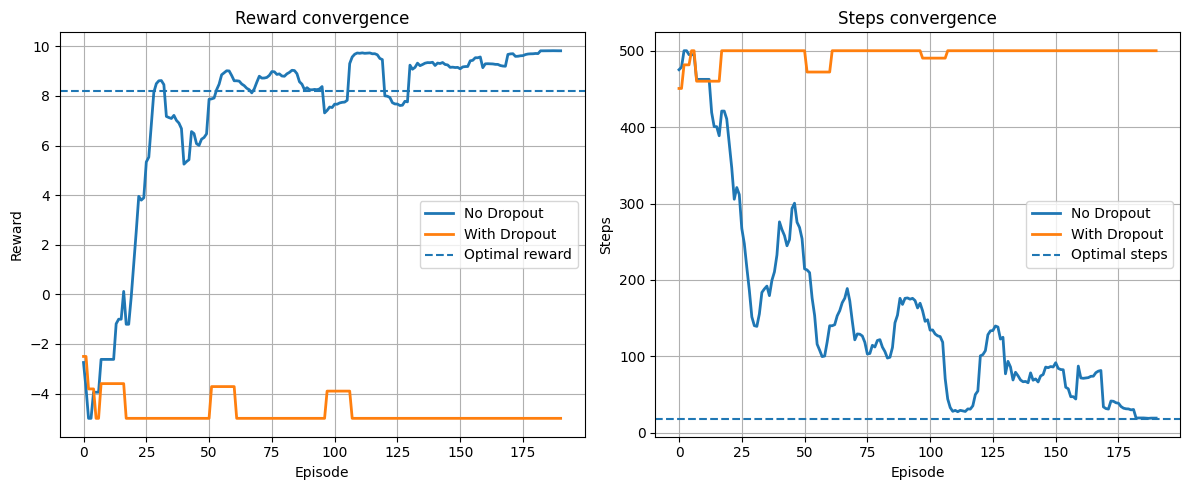

In [37]:
import numpy as np
import matplotlib.pyplot as plt

def smooth(y, window=10):
    return np.convolve(y, np.ones(window)/window, mode='valid')

plt.figure(figsize=(12,5))

# --- Reward ---
plt.subplot(1,2,1)
plt.plot(smooth(reward_no_dropout), linewidth=2, label="No Dropout")
plt.plot(smooth(reward_dropout), linewidth=2, label="With Dropout")
plt.axhline(y=8.2, linestyle='--', label="Optimal reward")
plt.title("Reward convergence")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.grid()

# --- Steps ---
plt.subplot(1,2,2)
plt.plot(smooth(steps_no_dropout), linewidth=2, label="No Dropout")
plt.plot(smooth(steps_dropout), linewidth=2, label="With Dropout")
plt.axhline(y=18, linestyle='--', label="Optimal steps")
plt.title("Steps convergence")
plt.xlabel("Episode")
plt.ylabel("Steps")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

### Simulation de la politique apprise

Cette fonction permet d’évaluer la politique apprise en simulant le comportement de l’agent et en reconstruisant une Q-table approximée à partir des prédictions du réseau, offrant une visualisation de la stratégie optimale.

Le modèle entraîné est chargé puis utilisé en mode évaluation, garantissant des prédictions déterministes. L’agent suit alors une politique purement exploitative, ce qui permet d’observer directement la qualité de la stratégie apprise. La trajectoire est visualisée dans la grille, et une carte thermique des Q-valeurs est générée afin d’analyser les actions optimales dans chaque état.

In [38]:
def SimulationDQNAgent(episode=180):
    grid_world = GridWorld(
        10, 10,
        blocked_positions=[(1, 1), (2, 2), (3, 3), (4, 4),
                           (3, 2), (3, 1), (5, 0),
                           (5, 5), (8, 9), (8, 8), (8, 7)]
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    dqn_model = DQN(grid_world.observation_space, grid_world.action_space)
    dqn_model.load_state_dict(torch.load(
        f'grid_world_learned_policy_dqn_{episode}.pt',
        map_location=device
    ))
    dqn_model.to(device)
    dqn_model.eval()

    agent = DQNAgent(alpha=0.5, gamma=0.9, epsilon=0.0, dqn_model=dqn_model)

    # --- DISPLAY ---
    pygame.init()
    screen = pygame.display.set_mode([
        (CELL_SIZE + MARGIN) * grid_world.width + MARGIN,
        (CELL_SIZE + MARGIN) * grid_world.height + MARGIN
    ])
    pygame.display.set_caption("GridWorld")

    running = True
    clock = pygame.time.Clock()
    visited_positions = []

    # --- SIMULATION ---
    while running and not grid_world.is_game_over():
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False

        state = grid_world.get_state()
        action = agent.get_action(state)
        grid_world.make_action(action)

        visited_positions.append(grid_world.player_position)

        screen.fill(BLACK)
        draw_grid(screen, grid_world)

        for i, pos in enumerate(visited_positions):
            x, y = pos
            alpha = int(100 + 155 * (i / len(visited_positions)))
            color = (255, 200, 200, alpha)

            temp_surface = pygame.Surface((CELL_SIZE, CELL_SIZE), pygame.SRCALPHA)
            pygame.draw.rect(temp_surface, color, [0, 0, CELL_SIZE, CELL_SIZE])
            screen.blit(
                temp_surface,
                [(MARGIN + CELL_SIZE) * x + MARGIN,
                 (MARGIN + CELL_SIZE) * y + MARGIN]
            )

        pygame.display.flip()
        clock.tick(10)

    # --- RECONSTRUCTION Q-TABLE ---
    q_table = np.zeros((grid_world.height, grid_world.width))
    action_table = np.empty((grid_world.height, grid_world.width), dtype=object)

    for i in range(grid_world.width):
        for j in range(grid_world.height):
            x, y = i, j

            state = np.zeros((2, grid_world.height, grid_world.width))

            # CORRECTION indices
            state[0][y, x] = 1
            for bx, by in grid_world.blocked_positions:
                state[1][by, bx] = 1

            q_values = agent.get_q_value(state).numpy().flatten()

            q_table[j, i] = np.max(q_values).round(2)
            action_table[j, i] = grid_world.actions[np.argmax(q_values)]

    print("q_table\n", q_table)
    print("action_table\n", action_table)

    pygame.quit()

    # --- VISUALISATION (OPTIONNEL MAIS RECOMMANDÉ) ---
    import matplotlib.pyplot as plt

    plt.figure(figsize=(8, 6))
    plt.imshow(q_table, cmap='viridis')
    plt.colorbar(label='Q-value')
    plt.title('Q-table (max Q per state)')

    for i in range(grid_world.height):
        for j in range(grid_world.width):
            plt.text(j, i, action_table[i, j],
                     ha='center', va='center', color='white', fontsize=8)

    plt.show()

### Analyse de la Q-table

#### **Analyse quantitative**
La carte thermique met en évidence une structure cohérente des valeurs de Q. Les valeurs les plus faibles (≈ 3.5–5) se situent dans la zone de départ (en haut à gauche), tandis que les valeurs les plus élevées (≈ 9–10) apparaissent à proximité de l’objectif (en bas à droite). Cette progression présente une monotonicité approximative vers l’objectif, conforme à l’équation de Bellman : plus un état est proche du but, plus sa valeur est élevée.
On observe également que certaines zones présentent des valeurs légèrement plus faibles, notamment à proximité des obstacles. Cela traduit une déformation locale du gradient de valeur, due au coût supplémentaire des détours nécessaires pour atteindre l’objectif.

#### **Analyse qualitative**
Du point de vue de la politique, les actions sont majoritairement orientées vers la droite et vers le bas, ce qui correspond à la direction optimale pour atteindre l’objectif situé en bas à droite. Cette cohérence globale indique que l’agent a appris une stratégie efficace.
Des variations locales (présence de “up” ou “left”) apparaissent à proximité des obstacles. Elles traduisent une adaptation de la politique pour contourner ces zones bloquées, ce qui confirme que l’agent prend en compte la structure de l’environnement.
Enfin, la politique est globalement stable : pour chaque état, une action dominante se dégage clairement, ce qui est caractéristique d’une bonne convergence.

#### **Discussion**
La Q-table obtenue présente une structure cohérente à la fois quantitativement et qualitativement. Le gradient de valeurs vers l’objectif, ainsi que sa déformation locale induite par les obstacles, montrent que le DQN a appris une politique proche de l’optimum et qu’il généralise correctement sur l’ensemble de la grille.

In [ ]:
SimulationDQNAgent(episode=180)

### Si on veut faire un bonnus : 
(a) Double DQN

## Conclusion

Ce travail a permis de mettre en œuvre un agent DQN dans un environnement GridWorld et d’illustrer concrètement les mécanismes fondamentaux du reinforcement learning avec approximation de fonction. L’utilisation d’un réseau de neurones permet de remplacer efficacement une Q-table, en généralisant à des états non vus et en capturant des relations non linéaires.

Les résultats montrent une convergence vers une politique quasi optimale en l’absence de dropout, avec une diminution du nombre d’étapes et une augmentation des récompenses. À l’inverse, l’introduction de dropout met en évidence les limites des techniques de régularisation classiques en RL, en raison du caractère bootstrap et non stationnaire de la cible.

L’analyse de la Q-table confirme que l’agent a appris une structure cohérente, avec un gradient de valeur orienté vers l’objectif et une adaptation locale aux obstacles. Cela traduit une bonne compréhension de l’environnement et une politique stable.
Cependant, cette approche reste limitée : elle est peu scalable et fortement sensible au choix des hyperparamètres, ce qui peut rendre l’apprentissage instable dans des environnements plus complexes.

Enfin, ce projet ouvre naturellement vers des améliorations plus avancées du DQN, telles que Double DQN pour réduire le biais de surestimation, le Prioritized Experience Replay (PER) pour un apprentissage plus efficace, ou encore le Dueling DQN qui permet de mieux estimer séparément la valeur d’un état et l’avantage d’une action.

In [ ]:
import matplotlib.pyplot as plt

# Supposons que vous avez une liste epsilon_history qui stocke les valeurs d'epsilon à chaque épisode
# Remplacez ceci par la variable réelle utilisée dans votre notebook
try:
    plt.figure(figsize=(8,4))
    plt.plot(epsilon_history, label='Epsilon')
    plt.xlabel('Episode')
    plt.ylabel('Epsilon')
    plt.title('Evolution de epsilon au cours de l\'apprentissage')
    plt.legend()
    plt.grid(True)
    plt.show()
except NameError:
    print("La variable 'epsilon_history' n'est pas définie. Veuillez vérifier le nom de la variable contenant l'évolution d'epsilon.")